In [1]:
# Code adapted from Machine Learning Engineering (Cornell Tech 2025)
import torch
import numpy as np
import random

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [2]:
from google.colab import drive
import sys
import os

# --- 1. Mount Drive ---
drive.mount('/content/drive')

# --- 2. Define Paths ---
# Path to the source code (loaders.py) - REMAINS ON DRIVE
DRIVE_CODE_PATH = '/content/drive/MyDrive/GoogleColab/dataforsptransformer/'

# Path to the zipped data file on Drive
ZIP_SOURCE_PATH = os.path.join(DRIVE_CODE_PATH, 'crc_markers.zip')

# Local disk folder where the FAST images will be unzipped
FAST_DATA_PATH = '/content/fast_data/'

# --- 3. Unzip Data (Performance Fix) ---
if not os.path.exists(FAST_DATA_PATH):
    print(f"🚀 Unzipping data from Drive to fast local disk: {FAST_DATA_PATH}")
    !mkdir -p "$FAST_DATA_PATH"
    # The -q flag silences the output. -d sets the destination directory.
    !unzip -q "$ZIP_SOURCE_PATH" -d "$FAST_DATA_PATH"

    print("✅ Data transfer complete. Starting new batch load test.")
else:
    print("Fast data directory already exists.")


# --- 4. Set Final Variables ---
# PROJECT_DIR for the rest of your notebook now points to the FAST images
PROJECT_DIR = FAST_DATA_PATH

# Add the Drive path for Python to find 'loaders.py' and other modules
if DRIVE_CODE_PATH not in sys.path:
    sys.path.append(DRIVE_CODE_PATH)
    print(f"✅ Added {DRIVE_CODE_PATH} to Python system path.")

Mounted at /content/drive
🚀 Unzipping data from Drive to fast local disk: /content/fast_data/
✅ Data transfer complete. Starting new batch load test.
✅ Added /content/drive/MyDrive/GoogleColab/dataforsptransformer/ to Python system path.


In [3]:
from google.colab import files

# This will open a 'Choose Files' button in your output cell
# Choose train_helpers.py
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving data_cleaning.py to data_cleaning.py
Saving graphformer.py to graphformer.py
Saving training.py to training.py
User uploaded file "data_cleaning.py" with length 8720 bytes
User uploaded file "graphformer.py" with length 8437 bytes
User uploaded file "training.py" with length 19619 bytes


In [27]:
!python3 data_cleaning.py

Computing KNN (k=5) for each graph separately...
Found 140 unique graphs
KNN computation complete! Total cells: 258385

Sample of cleaned data:
               GraphID  CellID  ...  Z:Z                                    KNN
0  reg001_A 1 reg001 1       0  ...   10            [22144, 50530, 3, 98132, 2]
1  reg001_A 1 reg001 1       1  ...   10  [33870, 50531, 118271, 33869, 118273]
2  reg001_A 1 reg001 1       2  ...   10            [3, 98132, 50530, 0, 22144]
3  reg001_A 1 reg001 1       3  ...   10            [50530, 98132, 2, 0, 22144]
4  reg001_A 1 reg001 1       4  ...   10      [118281, 98134, 118276, 5, 98140]

[5 rows x 6 columns]
Number cells: 258385, Number unique CellIDs 258385


In [28]:
import pandas as pd

df = pd.read_csv("/content/fast_data/CRC_clusters_neighborhoods_markers_cleaned.csv")
df.head()

,CellID,CD44 - stroma:Cyc_2_ch_2,FOXP3 - regulatory T cells:Cyc_2_ch_3,CD8 - cytotoxic T cells:Cyc_3_ch_2,p53 - tumor suppressor:Cyc_3_ch_3,GATA3 - Th2 helper T cells:Cyc_3_ch_4,CD45 - hematopoietic cells:Cyc_4_ch_2,T-bet - Th1 cells:Cyc_4_ch_3,beta-catenin - Wnt signaling:Cyc_4_ch_4,HLA-DR - MHC-II:Cyc_5_ch_2,...,CD68+Ki67+,CD68+PD-1+,CD8+ICOS+,CD8+Ki67+,CD8+PD-1+,Treg-ICOS+,Treg-Ki67+,Treg-PD-1+,GraphID,KNN
0,0,1.843591,17.398706,0.000000,59.391884,35.244526,0.000000,45.537239,258.346375,0.000000,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[22144, 50530, 3, 98132, 2]"
1,1,30.284525,18.375738,74.695236,271.420136,30.313547,0.000000,8.821254,668.978577,0.000000,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[33870, 50531, 118271, 33869, 118273]"
2,2,139.488510,249.746979,85.556976,705.369324,49.865829,8.435891,179.875778,480.811737,3.066591,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[3, 98132, 50530, 0, 22144]"
3,3,20.596886,81.759758,0.000000,0.000000,34.731583,0.000000,122.186234,145.830063,0.000000,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[50530, 98132, 2, 0, 22144]"
4,4,67.328728,122.195473,11.028284,325.076691,93.776245,0.000000,323.319305,987.071655,0.000000,...,0,0,0,0,0,0,0,0,reg001_A 1 reg001 1,"[118281, 98134, 118276, 5, 98140]"


In [6]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.6 MB/s eta 0:00:00


In [29]:
df.columns

Index(['CellID', 'CD44 - stroma:Cyc_2_ch_2',
       'FOXP3 - regulatory T cells:Cyc_2_ch_3',
       'CD8 - cytotoxic T cells:Cyc_3_ch_2',
       'p53 - tumor suppressor:Cyc_3_ch_3',
       'GATA3 - Th2 helper T cells:Cyc_3_ch_4',
       'CD45 - hematopoietic cells:Cyc_4_ch_2', 'T-bet - Th1 cells:Cyc_4_ch_3',
       'beta-catenin - Wnt signaling:Cyc_4_ch_4', 'HLA-DR - MHC-II:Cyc_5_ch_2',
       'PD-L1 - checkpoint:Cyc_5_ch_3', 'Ki67 - proliferation:Cyc_5_ch_4',
       'CD45RA - naive T cells:Cyc_6_ch_2', 'CD4 - T helper cells:Cyc_6_ch_3',
       'CD21 - DCs:Cyc_6_ch_4', 'MUC-1 - epithelia:Cyc_7_ch_2',
       'CD30 - costimulator:Cyc_7_ch_3', 'CD2 - T cells:Cyc_7_ch_4',
       'Vimentin - cytoplasm:Cyc_8_ch_2', 'CD20 - B cells:Cyc_8_ch_3',
       'LAG-3 - checkpoint:Cyc_8_ch_4', 'Na-K-ATPase - membranes:Cyc_9_ch_2',
       'CD5 - T cells:Cyc_9_ch_3', 'IDO-1 - metabolism:Cyc_9_ch_4',
       'Cytokeratin - epithelia:Cyc_10_ch_2',
       'CD11b - macrophages:Cyc_10_ch_3', 'CD56 - NK cells:C

## Setup Training Environment

In [8]:
# Add current directory to path so we can import training.py
import sys
import os
sys.path.append(os.getcwd())

from training import train_graphformer, simple_neighbor_average_baseline

# Start and end protein columns as identified in the notebook
START_PROTEIN = 'CD44 - stroma:Cyc_2_ch_2'
END_PROTEIN = 'CD138 - plasma cells:Cyc_21_ch_3'
protein_cols = df.columns[df.columns.get_loc(START_PROTEIN) : df.columns.get_loc(END_PROTEIN)+1].tolist()

## Level 1 Hyperparameter Optimization

We optimize the core capacity and stability parameters first:
1. **Learning Rate**: Determines convergence speed and stability.
2. **Max Neighbors (k)**: Determines the biological spatial context size.
3. **Number of Layers**: Determines the depth of the graph receptive field.

In [37]:
def run_and_score(params, *, rebuild_knn=False, test_baseline=False, epochs=3):
    # Report the hyperparameters
    print("Running with hyperparameters:")
    for k, v in params.items():
        print(f"  {k}: {v}")
    print(f"  rebuild_knn: {rebuild_knn}")
    print(f"  test_baseline: {test_baseline}")
    print(f"  num_epochs: {epochs}\n")

    # Train the model
    model, _, _ = train_graphformer(
        df,
        protein_start_col=START_PROTEIN,
        protein_end_col=END_PROTEIN,
        normalize=True,
        num_epochs=epochs,
        rebuild_knn=rebuild_knn,
        test_baseline=test_baseline,
        **params,
    )

    # Load the best model and return R²
    checkpoint = torch.load('best_graphformer_model.pt', weights_only=False)
    return checkpoint['r2']


In [10]:
graph_anchor = dict(max_neighbors=10, num_layers=3)
capacity_anchor = dict(hidden_dim=128, num_heads=4)

opt_anchor = dict(lr=1e-4, dropout=0.2, l2_reg=1e-4)

opt_sweep = [
    dict(lr=1e-5),
    dict(lr=1e-3),
    dict(l2_reg=0),
    dict(l2_reg=1e-3),
    dict(l2_reg=1e-5),
    dict(dropout=0.1),
    dict(dropout=0.3),
    dict(dropout=0.5),
]


Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 1e-05
  dropout: 0.2
  l2_reg: 0.0001
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: True
  test_baseline: True
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=10) relationships within train/test splits...
KNN rebuild complete!

Testing neighbor average baseline...

Neighbor Average Baseline - Best Proteins:
  Granzyme B - cytotoxicity:Cyc_13_ch_2              R²: -0.1281
  CD7 - T cells:Cyc_16_ch_3                          R²: -0.1530
  Chromogranin A - neuroendocrine:Cyc_17_ch_2        R²: -0.1621
  CD31 - vasculature:Cyc_19_ch_3                     R²: -0.1822
  CD15 - granulocytes:Cyc_14_ch_2                    R²: -0.1946
  CD8 - cytotoxic T cells:Cyc_3_ch_2                 R²: -0.2073
  HLA-DR - MHC-II:Cyc_5_ch_2                         R²: -0.21

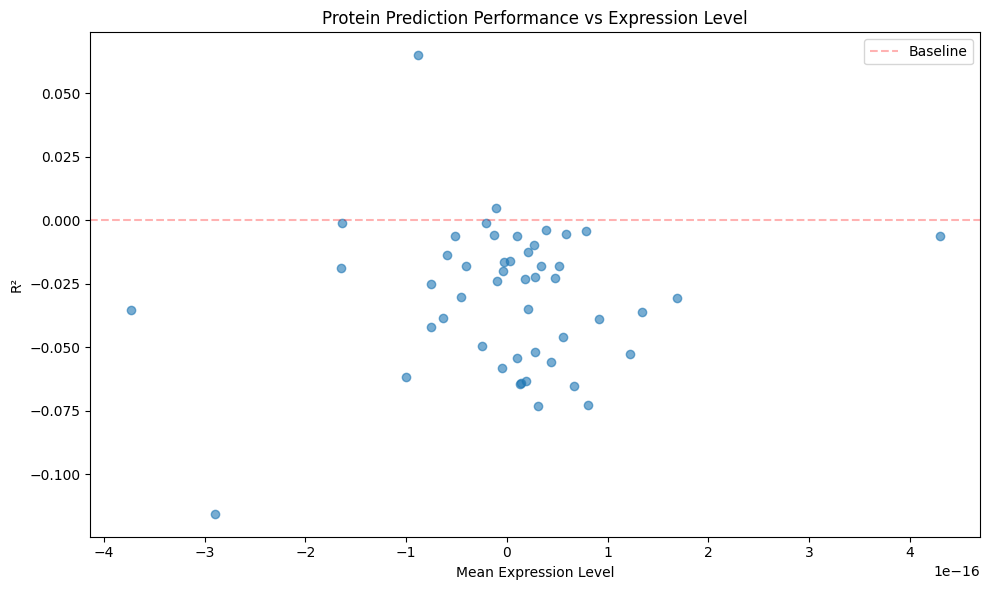


Correlation between mean expression and R²: 0.0899
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.2
  l2_reg: 0.0001
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.7959
  Test Loss: 0.6770, MAE: 0.10, R²: 0.2968, Mean Protein R²: 0.3416, Pearson r: 0.5646
  Saved best model (R²: 0.2968)
Epoch 2/3
  Train Loss: 0.7258
  Test Loss: 0.6299, MAE: 0.09, R²: 0.3462, Mean Protein R²: 0.3999, Pearson r: 0.6052
  Saved best model (R²: 0.3462)
Epoch 3/3
  Train Loss: 0.6955
  Test Loss: 0.5962, MAE: 0.09, R²: 0.3718, Mean Protein R²: 0.4295, Pearson r: 0.6300
  Saved best model (R²: 0.3718)
Best predicted proteins:
Protein                                                  R²     

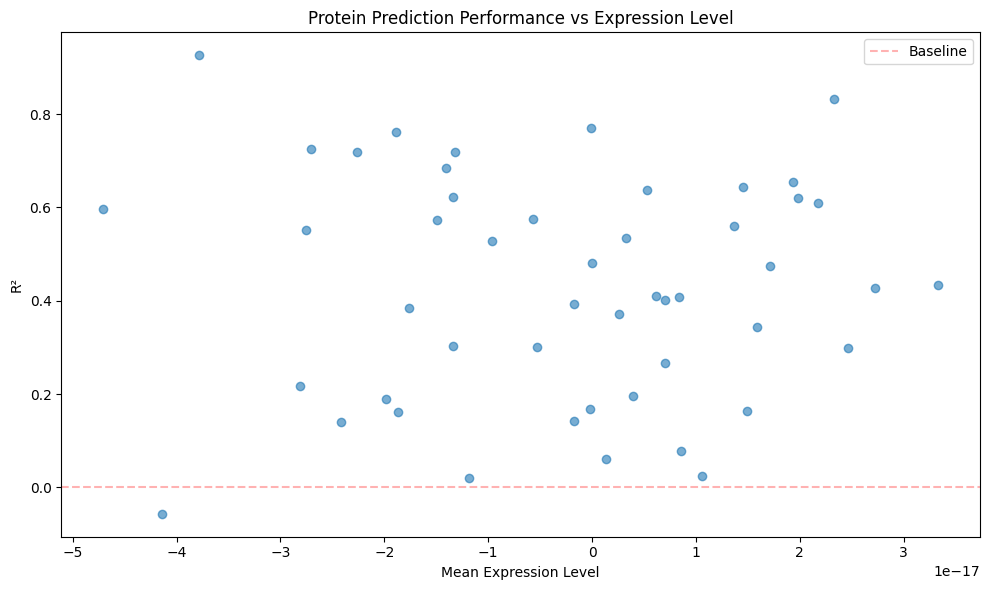


Correlation between mean expression and R²: -0.0173
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.0001
  dropout: 0.2
  l2_reg: 0
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8650
  Test Loss: 0.8117, MAE: 0.12, R²: 0.1887, Mean Protein R²: 0.2174, Pearson r: 0.4718
  Saved best model (R²: 0.1887)
Epoch 2/3
  Train Loss: 0.7820
  Test Loss: 0.7451, MAE: 0.11, R²: 0.2525, Mean Protein R²: 0.2914, Pearson r: 0.5264
  Saved best model (R²: 0.2525)
Epoch 3/3
  Train Loss: 0.7580
  Test Loss: 0.7215, MAE: 0.11, R²: 0.2654, Mean Protein R²: 0.3067, Pearson r: 0.5503
  Saved best model (R²: 0.2654)
Best predicted proteins:
Protein                                                  R²       Me

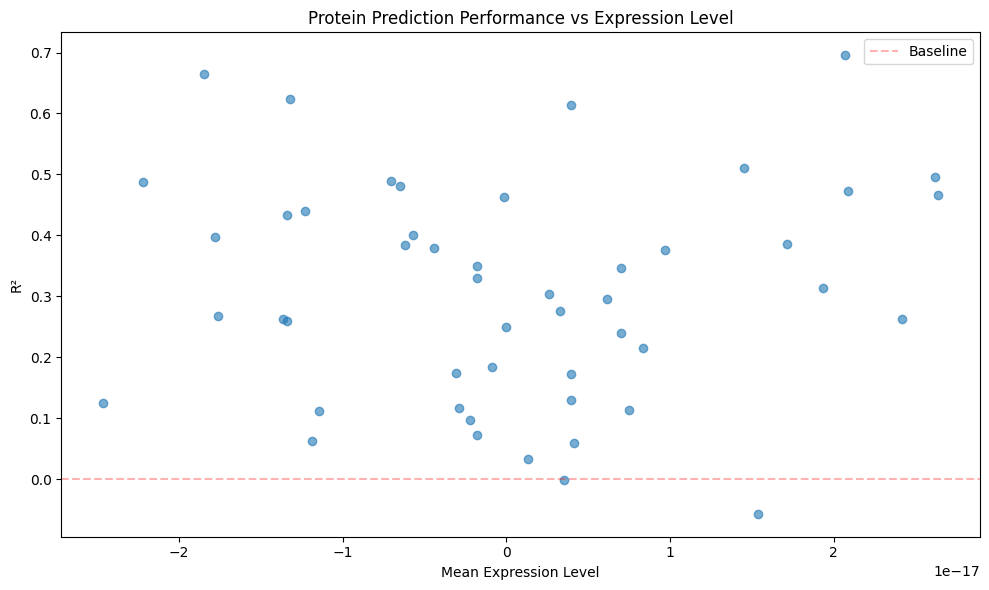


Correlation between mean expression and R²: 0.0353
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.0001
  dropout: 0.2
  l2_reg: 0.001
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8991
  Test Loss: 0.9150, MAE: 0.13, R²: 0.0753, Mean Protein R²: 0.0880, Pearson r: 0.3408
  Saved best model (R²: 0.0753)
Epoch 2/3
  Train Loss: 0.8507
  Test Loss: 0.8909, MAE: 0.13, R²: 0.1004, Mean Protein R²: 0.1214, Pearson r: 0.3642
  Saved best model (R²: 0.1004)
Epoch 3/3
  Train Loss: 0.8369
  Test Loss: 0.8841, MAE: 0.13, R²: 0.1084, Mean Protein R²: 0.1306, Pearson r: 0.3701
  Saved best model (R²: 0.1084)
Best predicted proteins:
Protein                                                  R²     

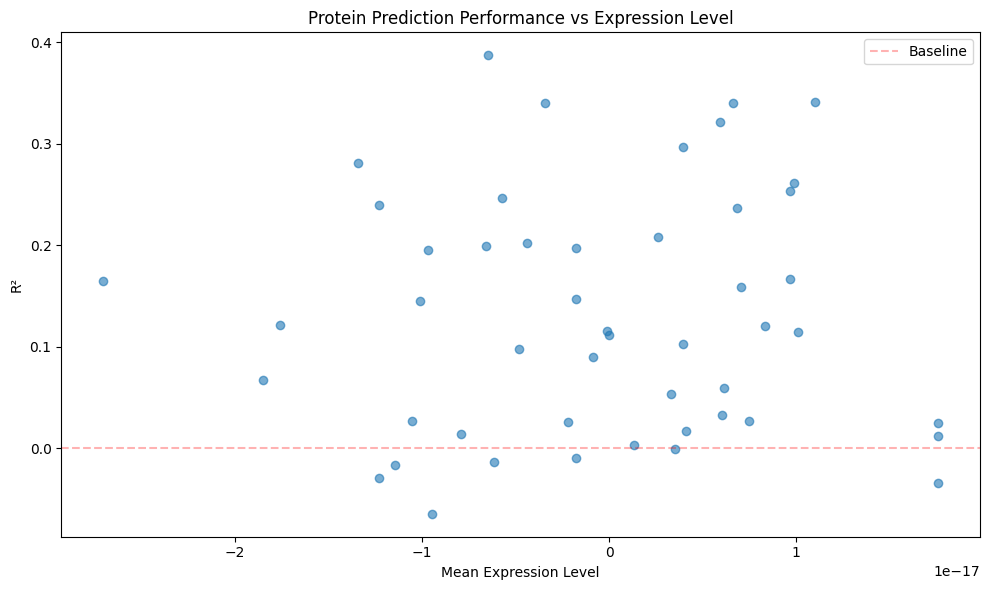


Correlation between mean expression and R²: 0.0094
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.0001
  dropout: 0.2
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8648
  Test Loss: 0.8138, MAE: 0.12, R²: 0.1809, Mean Protein R²: 0.2117, Pearson r: 0.4565
  Saved best model (R²: 0.1809)
Epoch 2/3
  Train Loss: 0.7824
  Test Loss: 0.7507, MAE: 0.11, R²: 0.2386, Mean Protein R²: 0.2773, Pearson r: 0.5167
  Saved best model (R²: 0.2386)
Epoch 3/3
  Train Loss: 0.7574
  Test Loss: 0.7294, MAE: 0.11, R²: 0.2566, Mean Protein R²: 0.2985, Pearson r: 0.5370
  Saved best model (R²: 0.2566)
Best predicted proteins:
Protein                                                  R²     

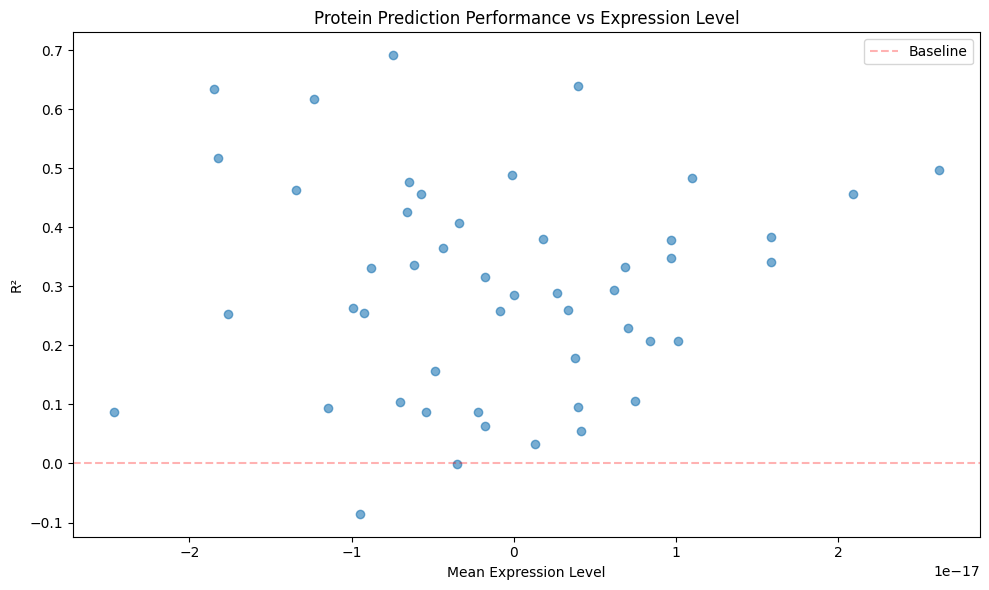


Correlation between mean expression and R²: 0.0405
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.0001
  dropout: 0.1
  l2_reg: 0.0001
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8546
  Test Loss: 0.8103, MAE: 0.12, R²: 0.1867, Mean Protein R²: 0.2159, Pearson r: 0.4619
  Saved best model (R²: 0.1867)
Epoch 2/3
  Train Loss: 0.7723
  Test Loss: 0.7351, MAE: 0.11, R²: 0.2562, Mean Protein R²: 0.3007, Pearson r: 0.5363
  Saved best model (R²: 0.2562)
Epoch 3/3
  Train Loss: 0.7471
  Test Loss: 0.7145, MAE: 0.11, R²: 0.2740, Mean Protein R²: 0.3186, Pearson r: 0.5509
  Saved best model (R²: 0.2740)
Best predicted proteins:
Protein                                                  R²    

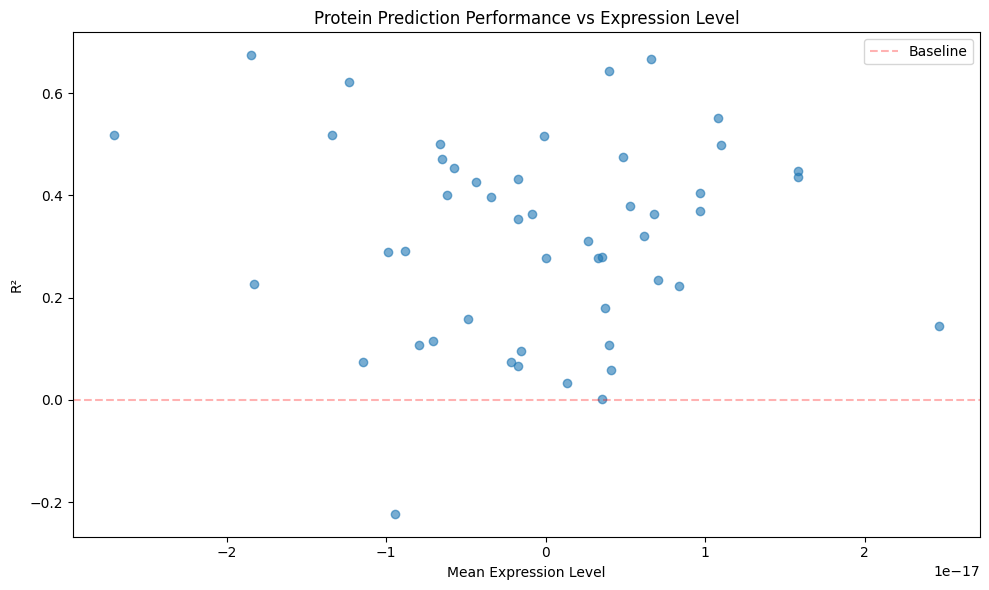


Correlation between mean expression and R²: -0.0301
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.0001
  dropout: 0.3
  l2_reg: 0.0001
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8848
  Test Loss: 0.8445, MAE: 0.13, R²: 0.1495, Mean Protein R²: 0.1722, Pearson r: 0.4376
  Saved best model (R²: 0.1495)
Epoch 2/3
  Train Loss: 0.8101
  Test Loss: 0.7889, MAE: 0.12, R²: 0.2060, Mean Protein R²: 0.2356, Pearson r: 0.4926
  Saved best model (R²: 0.2060)
Epoch 3/3
  Train Loss: 0.7874
  Test Loss: 0.7697, MAE: 0.12, R²: 0.2227, Mean Protein R²: 0.2570, Pearson r: 0.5086
  Saved best model (R²: 0.2227)
Best predicted proteins:
Protein                                                  R²    

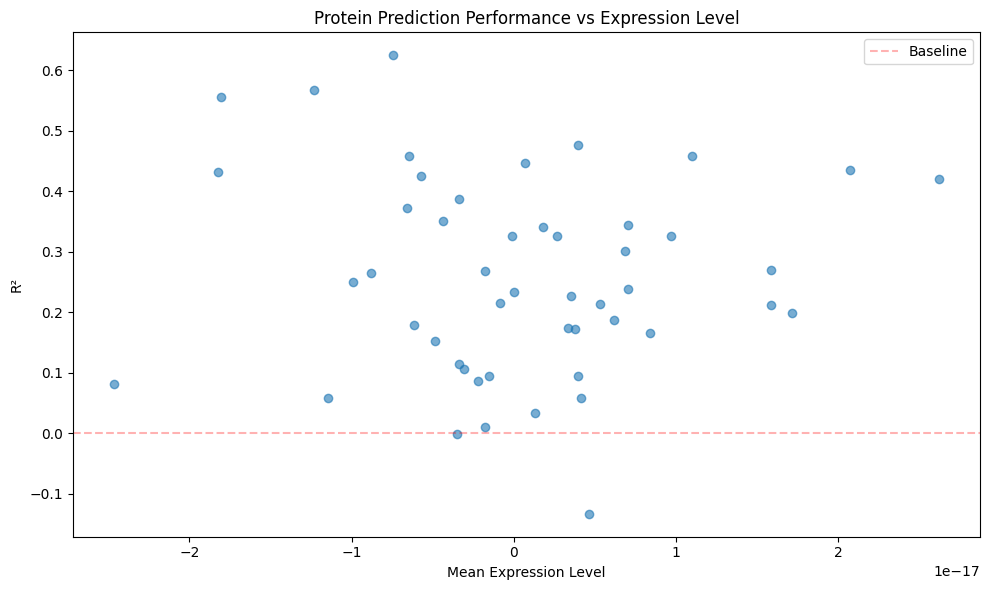


Correlation between mean expression and R²: -0.0364
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.0001
  dropout: 0.5
  l2_reg: 0.0001
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.9099
  Test Loss: 0.8753, MAE: 0.13, R²: 0.1176, Mean Protein R²: 0.1352, Pearson r: 0.4014
  Saved best model (R²: 0.1176)
Epoch 2/3
  Train Loss: 0.8449
  Test Loss: 0.8260, MAE: 0.12, R²: 0.1670, Mean Protein R²: 0.1927, Pearson r: 0.4535
  Saved best model (R²: 0.1670)
Epoch 3/3
  Train Loss: 0.8244
  Test Loss: 0.8211, MAE: 0.12, R²: 0.1702, Mean Protein R²: 0.1957, Pearson r: 0.4596
  Saved best model (R²: 0.1702)
Best predicted proteins:
Protein                                                  R²    

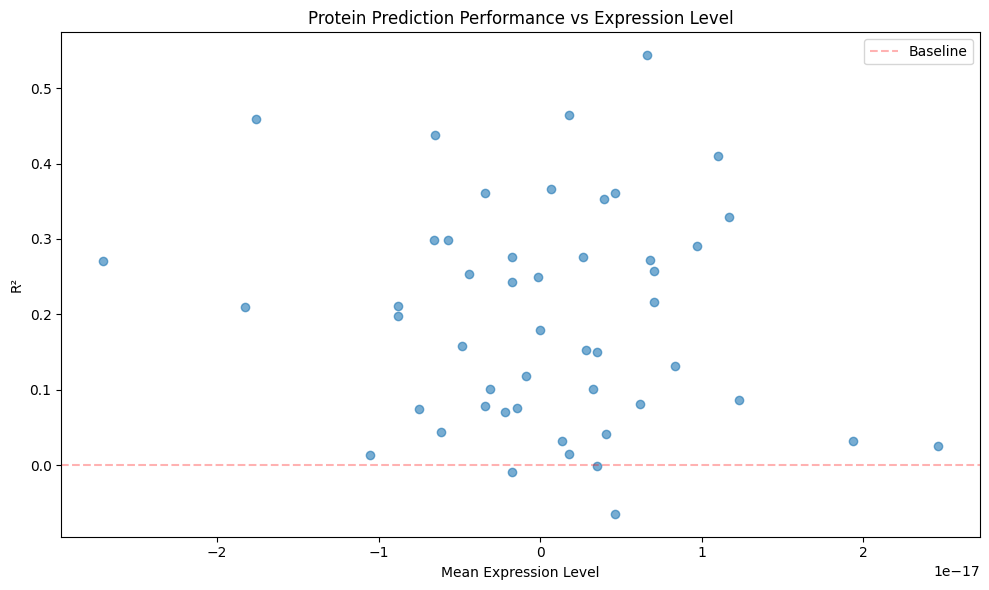


Correlation between mean expression and R²: -0.1380
Best R²: 0.3717793065945588
Best hyperparameters: {'lr': 0.001, 'dropout': 0.2, 'l2_reg': 0.0001}


In [11]:
best_opt_indep = opt_anchor
best_r2_indep = -float("inf")

first_pass = True

for delta in opt_sweep:
    params = {**opt_anchor, **delta}

    r2 = run_and_score(
        graph_anchor | params | capacity_anchor,
        rebuild_knn=first_pass,
        test_baseline=first_pass,
    )

    if r2 > best_r2_indep:
        best_r2_indep = r2
        best_opt_indep = params

    first_pass = False

print(f"Best R²: {best_r2_indep}")
print(f"Best hyperparameters: {best_opt_indep}")


Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 1e-05
  dropout: 0.2
  l2_reg: 0.0001
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.9560
  Test Loss: 1.0070, MAE: 0.14, R²: -0.0186, Mean Protein R²: -0.0275, Pearson r: 0.1093
  Saved best model (R²: -0.0186)
Epoch 2/3
  Train Loss: 0.9235
  Test Loss: 0.9762, MAE: 0.14, R²: 0.0020, Mean Protein R²: -0.0012, Pearson r: 0.2470
  Saved best model (R²: 0.0020)
Epoch 3/3
  Train Loss: 0.9104
  Test Loss: 0.9674, MAE: 0.14, R²: 0.0120, Mean Protein R²: 0.0103, Pearson r: 0.2804
  Saved best model (R²: 0.0120)
Best predicted proteins:
Protein                                                  R²       Mean        Std        Max
--------------------

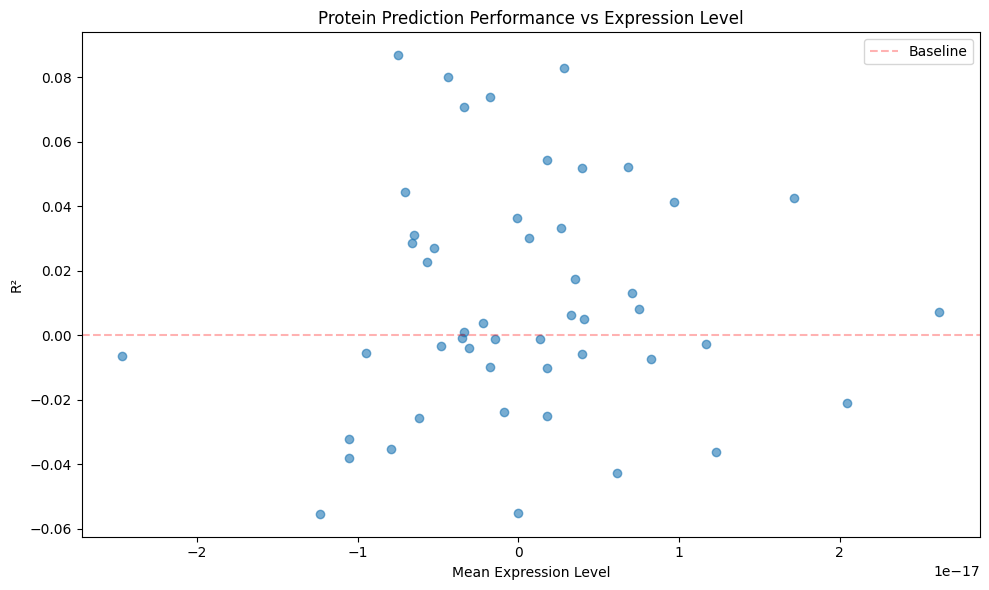


Correlation between mean expression and R²: 0.0589
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.2
  l2_reg: 0
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.7782
  Test Loss: 0.6639, MAE: 0.10, R²: 0.3146, Mean Protein R²: 0.3684, Pearson r: 0.5663
  Saved best model (R²: 0.3146)
Epoch 2/3
  Train Loss: 0.7006
  Test Loss: 0.6075, MAE: 0.09, R²: 0.3662, Mean Protein R²: 0.4189, Pearson r: 0.6284
  Saved best model (R²: 0.3662)
Epoch 3/3
  Train Loss: 0.6700
  Test Loss: 0.5895, MAE: 0.09, R²: 0.3795, Mean Protein R²: 0.4432, Pearson r: 0.6321
  Saved best model (R²: 0.3795)
Best predicted proteins:
Protein                                                  R²       Mea

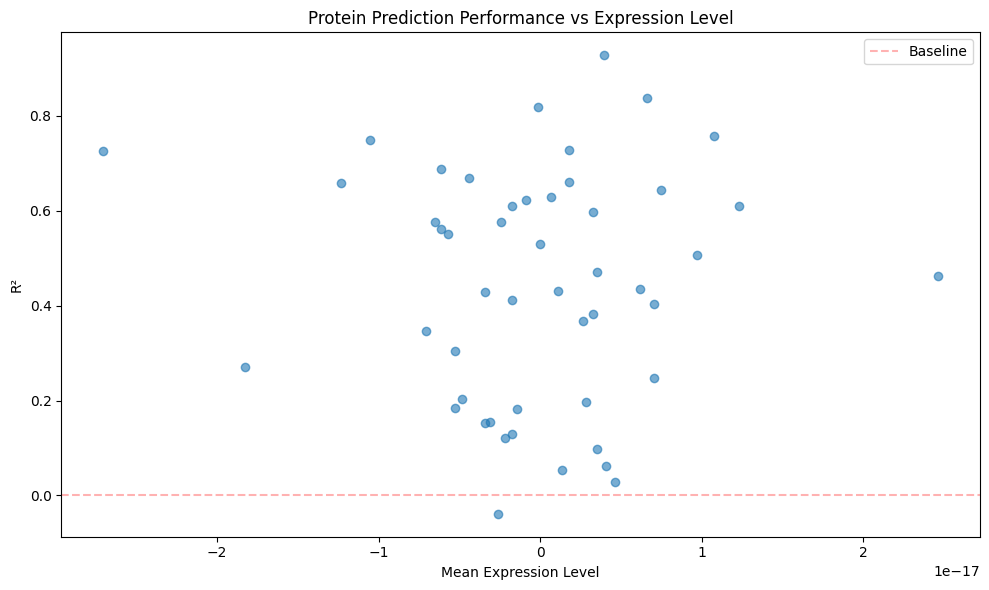


Correlation between mean expression and R²: -0.0102
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.2
  l2_reg: 0.001
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8560
  Test Loss: 0.8633, MAE: 0.13, R²: 0.1421, Mean Protein R²: 0.1557, Pearson r: 0.4172
  Saved best model (R²: 0.1421)
Epoch 2/3
  Train Loss: 0.8052
  Test Loss: 0.8257, MAE: 0.13, R²: 0.1743, Mean Protein R²: 0.1968, Pearson r: 0.4452
  Saved best model (R²: 0.1743)
Epoch 3/3
  Train Loss: 0.7880
  Test Loss: 0.7963, MAE: 0.12, R²: 0.1999, Mean Protein R²: 0.2226, Pearson r: 0.4863
  Saved best model (R²: 0.1999)
Best predicted proteins:
Protein                                                  R²     

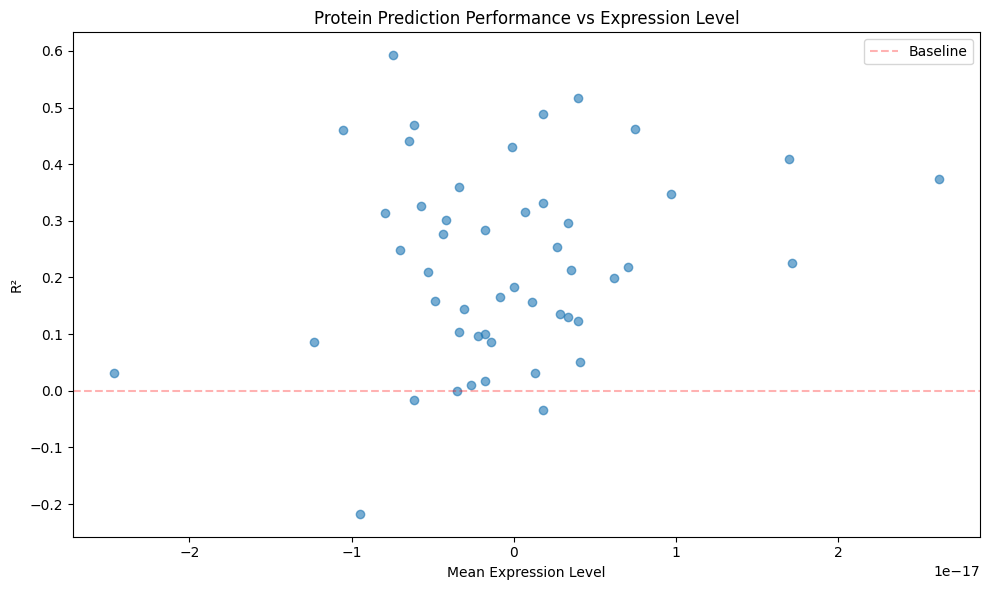


Correlation between mean expression and R²: 0.2212
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.2
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.7794
  Test Loss: 0.6542, MAE: 0.10, R²: 0.3208, Mean Protein R²: 0.3724, Pearson r: 0.5859
  Saved best model (R²: 0.3208)
Epoch 2/3
  Train Loss: 0.7053
  Test Loss: 0.6132, MAE: 0.09, R²: 0.3587, Mean Protein R²: 0.4164, Pearson r: 0.6148
  Saved best model (R²: 0.3587)
Epoch 3/3
  Train Loss: 0.6722
  Test Loss: 0.5657, MAE: 0.08, R²: 0.4011, Mean Protein R²: 0.4616, Pearson r: 0.6489
  Saved best model (R²: 0.4011)
Best predicted proteins:
Protein                                                  R²      

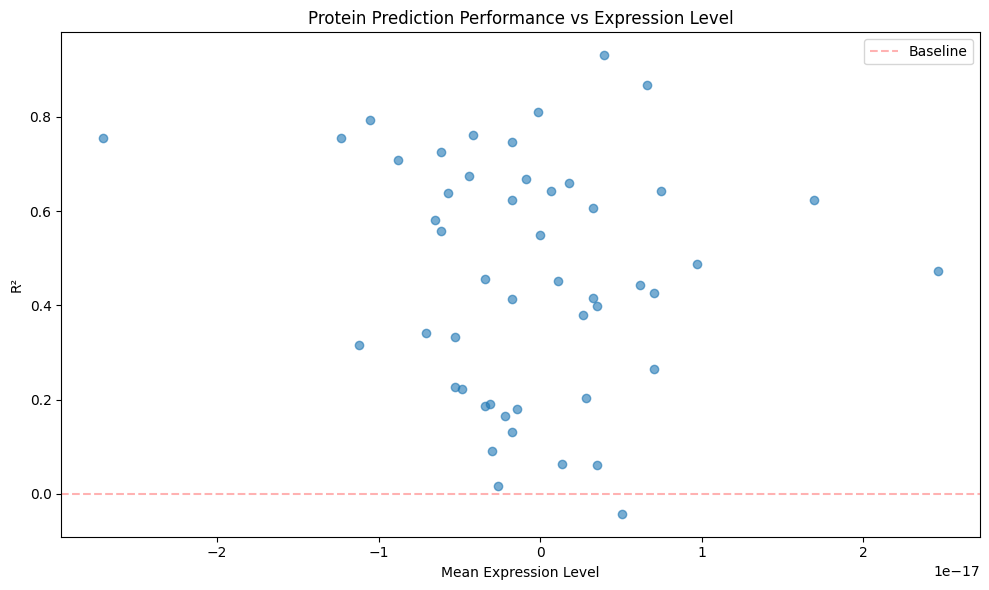


Correlation between mean expression and R²: -0.1125
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.7575
  Test Loss: 0.6473, MAE: 0.10, R²: 0.3239, Mean Protein R²: 0.3810, Pearson r: 0.5909
  Saved best model (R²: 0.3239)
Epoch 2/3
  Train Loss: 0.6793
  Test Loss: 0.5847, MAE: 0.08, R²: 0.3873, Mean Protein R²: 0.4535, Pearson r: 0.6309
  Saved best model (R²: 0.3873)
Epoch 3/3
  Train Loss: 0.6479
  Test Loss: 0.5592, MAE: 0.07, R²: 0.4089, Mean Protein R²: 0.4775, Pearson r: 0.6499
  Saved best model (R²: 0.4089)
Best predicted proteins:
Protein                                                  R²     

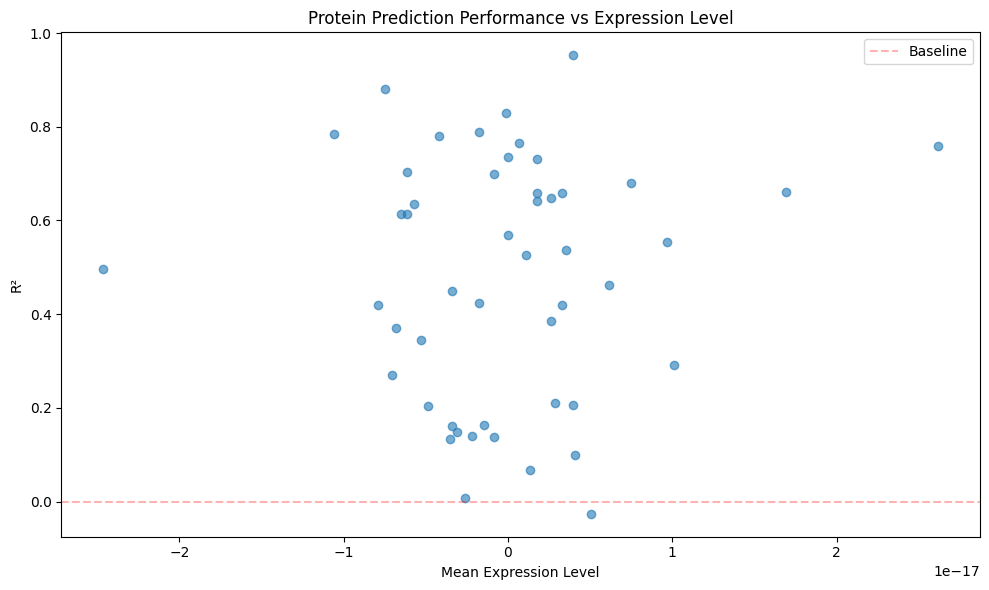


Correlation between mean expression and R²: 0.0693
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.3
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.7978
  Test Loss: 0.6814, MAE: 0.11, R²: 0.2943, Mean Protein R²: 0.3345, Pearson r: 0.5723
  Saved best model (R²: 0.2943)
Epoch 2/3
  Train Loss: 0.7267
  Test Loss: 0.6284, MAE: 0.09, R²: 0.3421, Mean Protein R²: 0.3945, Pearson r: 0.6064
  Saved best model (R²: 0.3421)
Epoch 3/3
  Train Loss: 0.6968
  Test Loss: 0.6092, MAE: 0.09, R²: 0.3597, Mean Protein R²: 0.4153, Pearson r: 0.6221
  Saved best model (R²: 0.3597)
Best predicted proteins:
Protein                                                  R²      

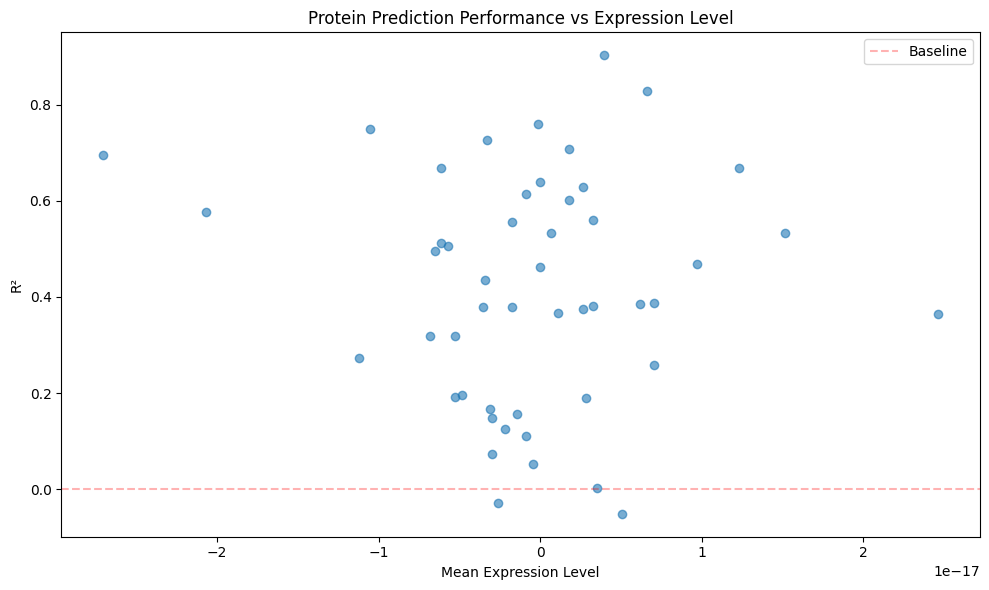


Correlation between mean expression and R²: -0.0456
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.5
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8398
  Test Loss: 0.7516, MAE: 0.12, R²: 0.2297, Mean Protein R²: 0.2629, Pearson r: 0.4980
  Saved best model (R²: 0.2297)
Epoch 2/3
  Train Loss: 0.7824
  Test Loss: 0.7169, MAE: 0.11, R²: 0.2459, Mean Protein R²: 0.2876, Pearson r: 0.5372
  Saved best model (R²: 0.2459)
Epoch 3/3
  Train Loss: 0.7540
  Test Loss: 0.6825, MAE: 0.11, R²: 0.2797, Mean Protein R²: 0.3265, Pearson r: 0.5644
  Saved best model (R²: 0.2797)
Best predicted proteins:
Protein                                                  R²     

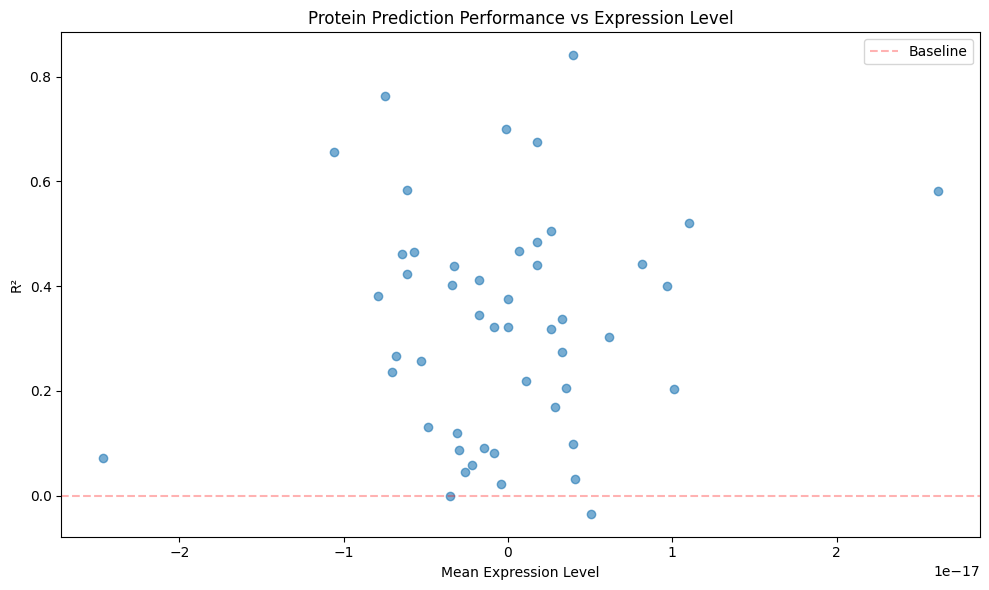


Correlation between mean expression and R²: 0.1223
Best R²: 0.4089019249700728
Best hyperparameters: {'lr': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05}


In [12]:
best_opt = best_opt_indep.copy()
best_r2 = best_r2_indep

for delta in opt_sweep:
    # Only try changes not already applied
    params = {**best_opt, **delta}

    if params == best_opt:
        continue

    r2 = run_and_score(
        graph_anchor | params | capacity_anchor,
        rebuild_knn=False,
        test_baseline=False,
    )

    if r2 > best_r2:
        best_r2 = r2
        best_opt = params

print(f"Best R²: {best_r2}")
print(f"Best hyperparameters: {best_opt}")


In [19]:
capacity_anchor = dict(hidden_dim=128, num_heads=4)
opt_anchor = best_opt          # from optimizer sweep
graph_anchor = dict(max_neighbors=10, num_layers=3)

graph_sweep = [
    dict(max_neighbors=5),
    dict(max_neighbors=10),
    dict(max_neighbors=20),
    dict(max_neighbors=50),
]


In [36]:
# Python 3.4+ way
import importlib
import training  # your module name

# Force reload
importlib.reload(training)

from training import train_graphformer, simple_neighbor_average_baseline


Running with hyperparameters:
  max_neighbors: 5
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: True
  test_baseline: True
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=5) relationships within train/test splits...
KNN rebuild complete!

Testing neighbor average baseline...

Neighbor Average Baseline - Best Proteins:
  Granzyme B - cytotoxicity:Cyc_13_ch_2              R²: -0.2004
  CD7 - T cells:Cyc_16_ch_3                          R²: -0.2344
  Chromogranin A - neuroendocrine:Cyc_17_ch_2        R²: -0.2671
  CD31 - vasculature:Cyc_19_ch_3                     R²: -0.2937
  CD8 - cytotoxic T cells:Cyc_3_ch_2                 R²: -0.2948
  FOXP3 - regulatory T cells:Cyc_2_ch_3              R²: -0.3081
  BCL-2 - apoptosis:Cyc_11_ch_3                      R²: -0.3108


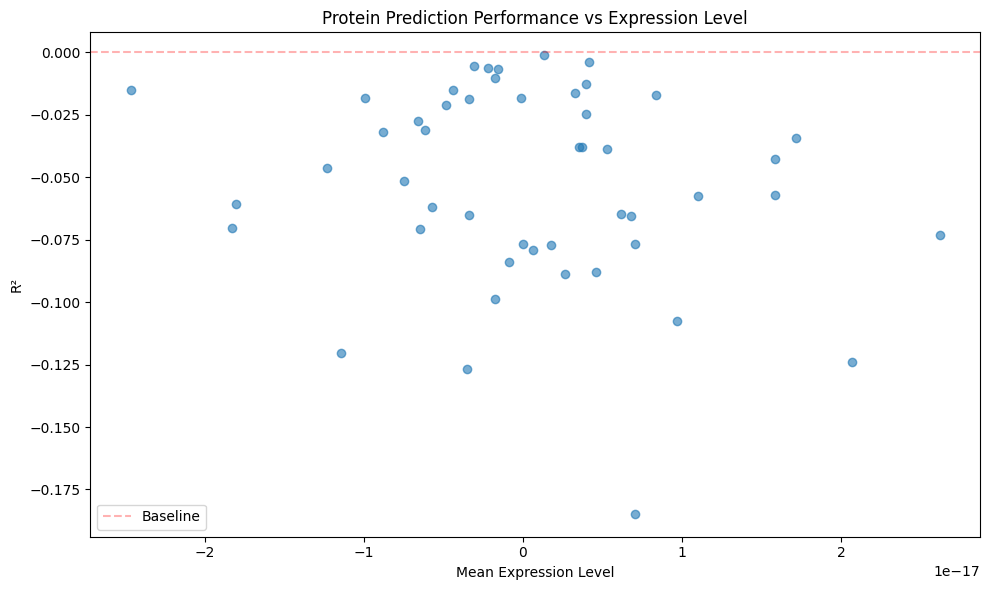


Correlation between mean expression and R²: -0.1905
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: True
  test_baseline: True
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=10) relationships within train/test splits...
KNN rebuild complete!

Testing neighbor average baseline...

Neighbor Average Baseline - Best Proteins:
  Granzyme B - cytotoxicity:Cyc_13_ch_2              R²: -0.1281
  CD7 - T cells:Cyc_16_ch_3                          R²: -0.1530
  Chromogranin A - neuroendocrine:Cyc_17_ch_2        R²: -0.1621
  CD31 - vasculature:Cyc_19_ch_3                     R²: -0.1822
  CD15 - granulocytes:Cyc_14_ch_2                    R²: -0.1946
  CD8 - cytotoxic T cells:Cyc_3_ch_2                 R²: -0.2073
  HLA-DR -

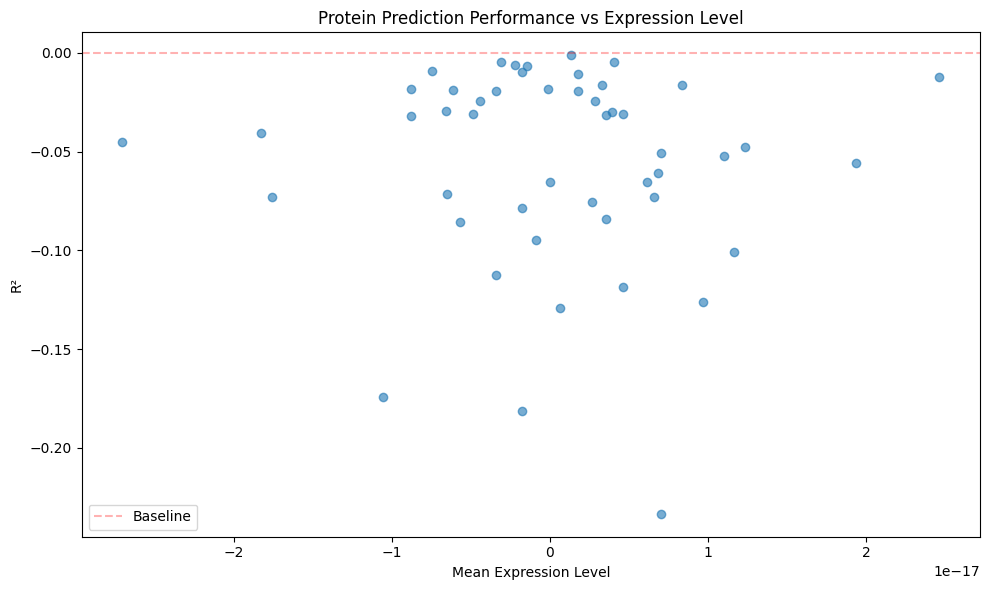


Correlation between mean expression and R²: -0.0453
Running with hyperparameters:
  max_neighbors: 20
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: True
  test_baseline: True
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=20) relationships within train/test splits...
KNN rebuild complete!

Testing neighbor average baseline...

Neighbor Average Baseline - Best Proteins:
  Granzyme B - cytotoxicity:Cyc_13_ch_2              R²: -0.0700
  CD31 - vasculature:Cyc_19_ch_3                     R²: -0.1003
  CD7 - T cells:Cyc_16_ch_3                          R²: -0.1029
  Chromogranin A - neuroendocrine:Cyc_17_ch_2        R²: -0.1164
  CD15 - granulocytes:Cyc_14_ch_2                    R²: -0.1244
  CD34 - vasculature:Cyc_20_ch_3                     R²: -0.1523
  HLA-DR -

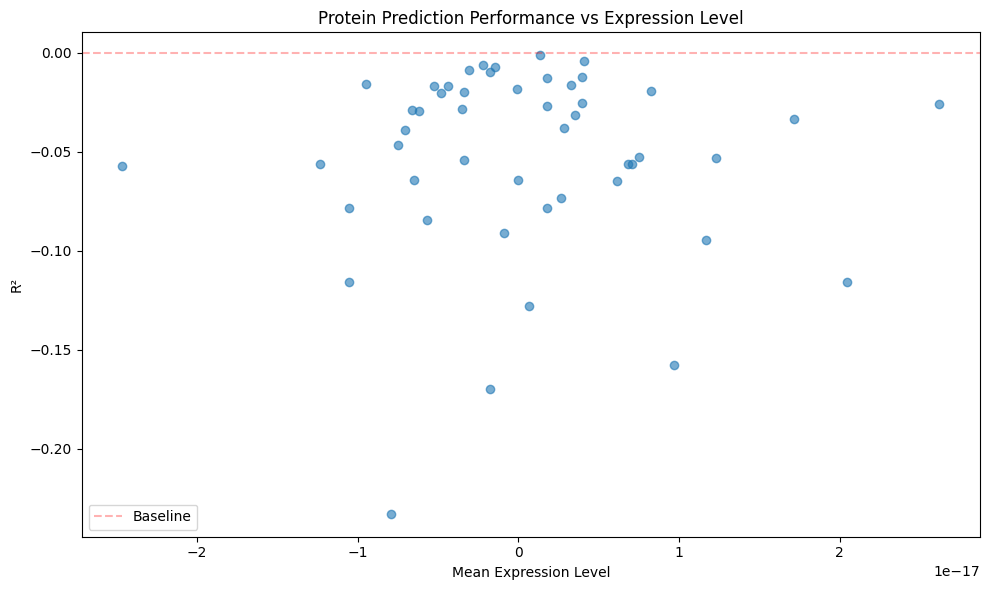


Correlation between mean expression and R²: 0.0136
Running with hyperparameters:
  max_neighbors: 50
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: True
  test_baseline: True
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=50) relationships within train/test splits...
KNN rebuild complete!

Testing neighbor average baseline...

Neighbor Average Baseline - Best Proteins:
  Granzyme B - cytotoxicity:Cyc_13_ch_2              R²: -0.0359
  CD31 - vasculature:Cyc_19_ch_3                     R²: -0.0410
  CD7 - T cells:Cyc_16_ch_3                          R²: -0.0688
  Chromogranin A - neuroendocrine:Cyc_17_ch_2        R²: -0.0791
  CD15 - granulocytes:Cyc_14_ch_2                    R²: -0.0822
  CD34 - vasculature:Cyc_20_ch_3                     R²: -0.0835
  HLA-DR -

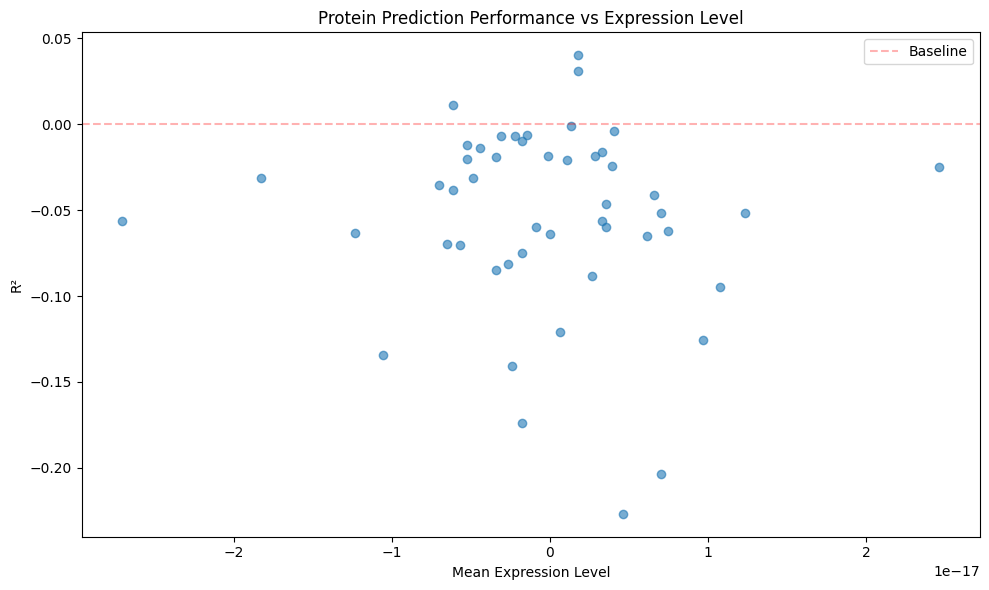


Correlation between mean expression and R²: -0.0877
Best R²: -0.030448956998108345
Best hyperparameters: {'max_neighbors': 20, 'num_layers': 3}


In [38]:
best_graph_indep = graph_anchor.copy()
best_r2_indep = -float("inf")

prev_k = None
first_pass = True

for delta in graph_sweep:
    params = {**graph_anchor, **delta}
    current_k = params['max_neighbors']

    # Rebuild KNN if first pass OR k changed
    k_changed = first_pass or (current_k != prev_k)

    r2 = run_and_score(
        params | opt_anchor | capacity_anchor,
        rebuild_knn=k_changed,      # rebuild only when needed
        test_baseline=k_changed,   # baseline only on first pass
    )

    if r2 > best_r2_indep:
        best_r2_indep = r2
        best_graph_indep = params.copy()

    first_pass = False
    prev_k = current_k

print(f"Best R²: {best_r2_indep}")
print(f"Best hyperparameters: {best_graph_indep}")


Running with hyperparameters:
  max_neighbors: 5
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: True
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=5) relationships within train/test splits...
KNN rebuild complete!
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8351
  Test Loss: 1.1640, MAE: 0.16, R²: -0.0415, Mean Protein R²: -0.0605, Pearson r: 0.0128
  Saved best model (R²: -0.0415)
Epoch 2/3
  Train Loss: 0.7875
  Test Loss: 1.1761, MAE: 0.16, R²: -0.0423, Mean Protein R²: -0.0594, Pearson r: 0.0072
Epoch 3/3
  Train Loss: 0.7657
  Test Loss: 1.1664, MAE: 0.16, R²: -0.0388, Mean Protein R²: -0.0553, Pearson r: 0.0170
  Saved best model (R²: -0.0388)
Best predicted proteins:
Protein                                                  R

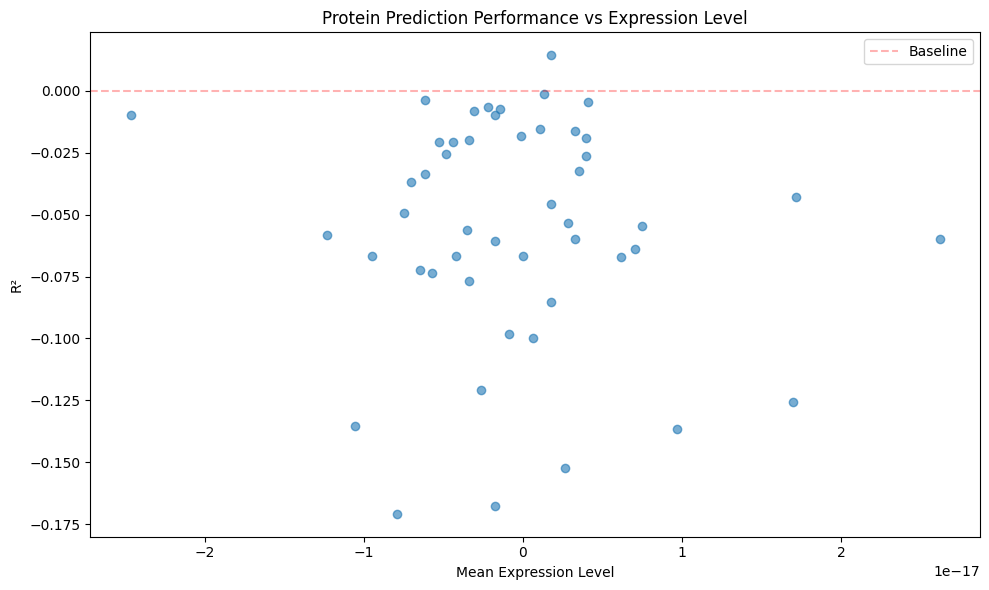


Correlation between mean expression and R²: -0.0862
Running with hyperparameters:
  max_neighbors: 10
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: True
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=10) relationships within train/test splits...
KNN rebuild complete!
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8207
  Test Loss: 1.1613, MAE: 0.16, R²: -0.0370, Mean Protein R²: -0.0603, Pearson r: 0.0178
  Saved best model (R²: -0.0370)
Epoch 2/3
  Train Loss: 0.7789
  Test Loss: 1.1785, MAE: 0.16, R²: -0.0479, Mean Protein R²: -0.0674, Pearson r: 0.0086
Epoch 3/3
  Train Loss: 0.7599
  Test Loss: 1.1872, MAE: 0.16, R²: -0.0520, Mean Protein R²: -0.0774, Pearson r: 0.0075
Best predicted proteins:
Protein                             

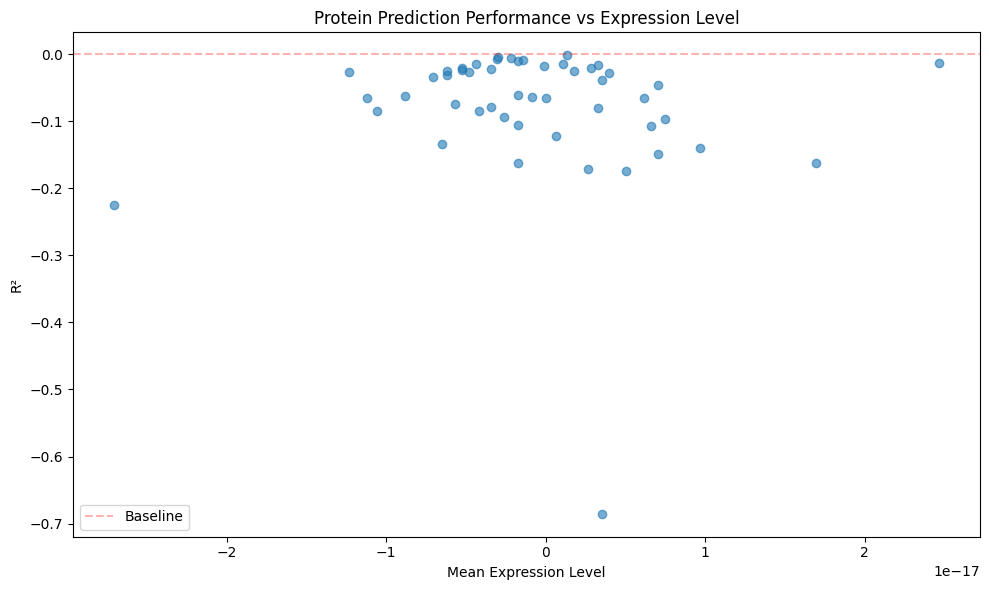


Correlation between mean expression and R²: -0.0568
Running with hyperparameters:
  max_neighbors: 50
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 4
  rebuild_knn: True
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Rebuilding KNN (k=50) relationships within train/test splits...
KNN rebuild complete!
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.8025
  Test Loss: 1.1428, MAE: 0.16, R²: -0.0312, Mean Protein R²: -0.0450, Pearson r: 0.0376
  Saved best model (R²: -0.0312)
Epoch 2/3
  Train Loss: 0.7703
  Test Loss: 1.1700, MAE: 0.16, R²: -0.0452, Mean Protein R²: -0.0670, Pearson r: 0.0244
Epoch 3/3
  Train Loss: 0.7543
  Test Loss: 1.1613, MAE: 0.16, R²: -0.0385, Mean Protein R²: -0.0537, Pearson r: 0.0225
Best predicted proteins:
Protein                             

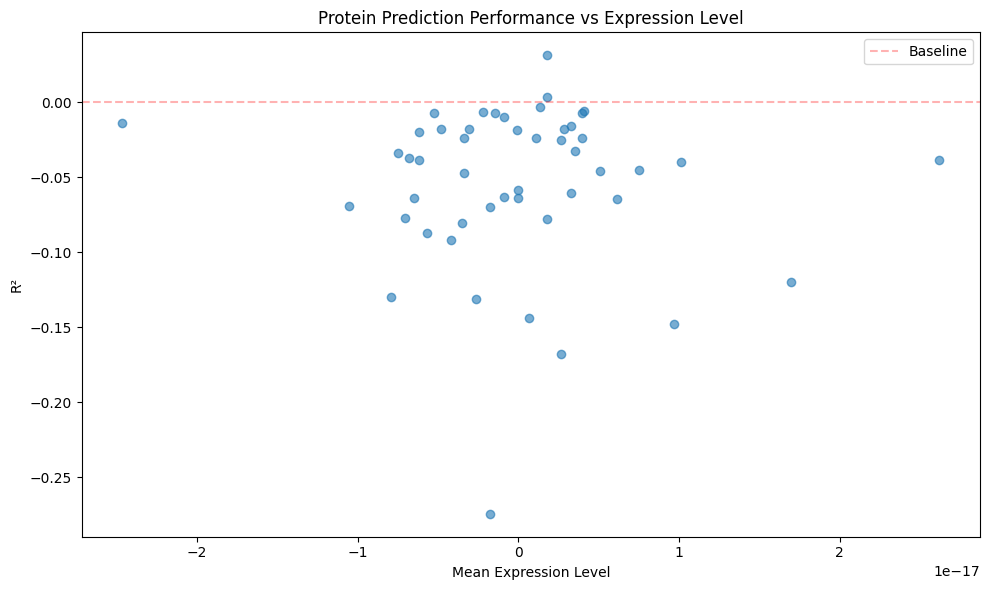


Correlation between mean expression and R²: -0.0514
Best R²: -0.030448956998108345
Best hyperparameters: {'max_neighbors': 20, 'num_layers': 3}


In [39]:
best_graph = best_graph_indep.copy()
best_r2 = best_r2_indep

prev_k = best_graph['max_neighbors']

for delta in graph_sweep:
    params = {**best_graph, **delta}
    current_k = params['max_neighbors']

    if params == best_graph:
        continue

    rebuild_KNN = current_k != prev_k

    r2 = run_and_score(
        params | opt_anchor | capacity_anchor,
        rebuild_knn=rebuild_KNN,
        test_baseline=False,
    )

    if r2 > best_r2:
        best_r2 = r2
        best_graph = params
        prev_k = current_k

print(f"Best R²: {best_r2}")
print(f"Best hyperparameters: {best_graph}")


In [40]:
capacity_sweep = [
    dict(hidden_dim=64),
    dict(hidden_dim=256),
    dict(num_heads=2),
    dict(num_heads=8),
]


Running with hyperparameters:
  max_neighbors: 20
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 64
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 160,497
Epoch 1/3
  Train Loss: 0.8044
  Test Loss: 0.6938, MAE: 0.11, R²: 0.2788, Mean Protein R²: 0.3204, Pearson r: 0.5473
  Saved best model (R²: 0.2788)
Epoch 2/3
  Train Loss: 0.7209
  Test Loss: 0.6468, MAE: 0.10, R²: 0.3218, Mean Protein R²: 0.3740, Pearson r: 0.5852
  Saved best model (R²: 0.3218)
Epoch 3/3
  Train Loss: 0.6917
  Test Loss: 0.6220, MAE: 0.09, R²: 0.3504, Mean Protein R²: 0.4065, Pearson r: 0.6057
  Saved best model (R²: 0.3504)
Best predicted proteins:
Protein                                                  R²       Mean        Std        Max
-------------------------

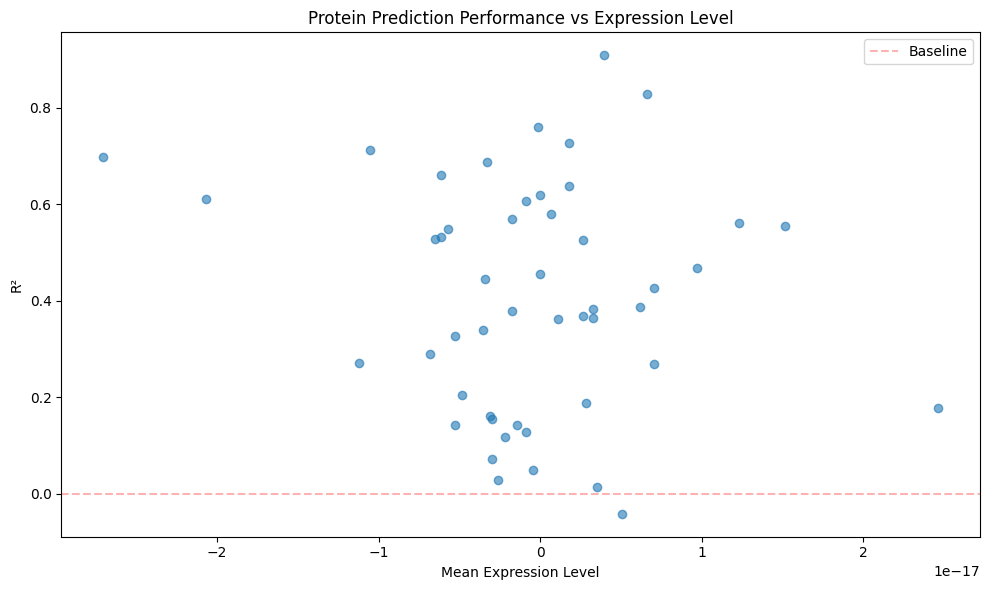


Correlation between mean expression and R²: -0.1184
Running with hyperparameters:
  max_neighbors: 20
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 256
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 2,460,465
Epoch 1/3
  Train Loss: 0.7667
  Test Loss: 0.6589, MAE: 0.10, R²: 0.3147, Mean Protein R²: 0.3658, Pearson r: 0.5641
  Saved best model (R²: 0.3147)
Epoch 2/3
  Train Loss: 0.6881
  Test Loss: 0.5918, MAE: 0.08, R²: 0.3977, Mean Protein R²: 0.4445, Pearson r: 0.6424
  Saved best model (R²: 0.3977)
Epoch 3/3
  Train Loss: 0.6498
  Test Loss: 0.5296, MAE: 0.07, R²: 0.4416, Mean Protein R²: 0.5047, Pearson r: 0.6723
  Saved best model (R²: 0.4416)
Best predicted proteins:
Protein                                                  R²   

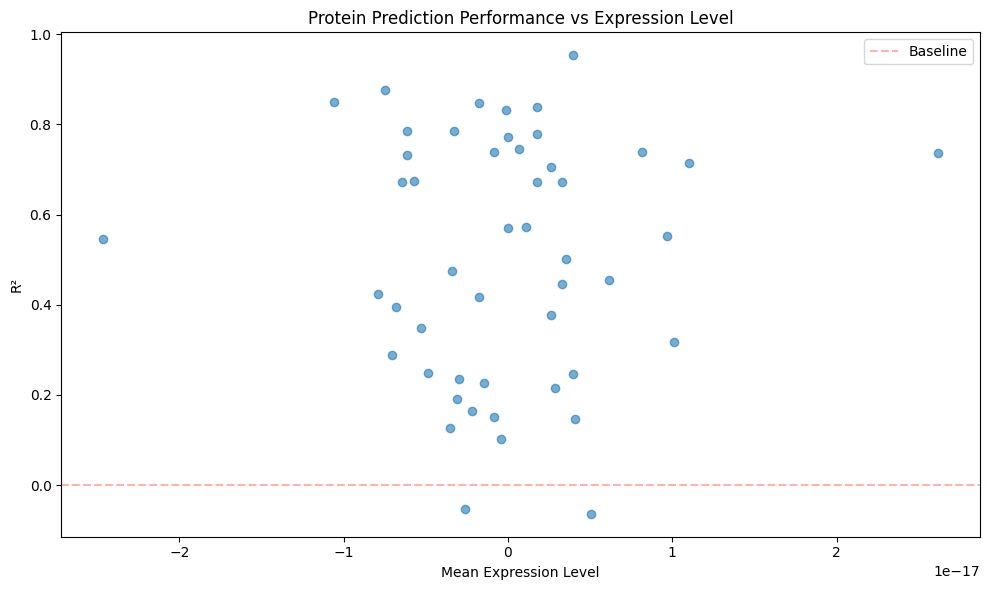


Correlation between mean expression and R²: 0.0359
Running with hyperparameters:
  max_neighbors: 20
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 2
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.7710
  Test Loss: 0.6324, MAE: 0.09, R²: 0.3518, Mean Protein R²: 0.3974, Pearson r: 0.6026
  Saved best model (R²: 0.3518)
Epoch 2/3
  Train Loss: 0.6882
  Test Loss: 0.5822, MAE: 0.08, R²: 0.3867, Mean Protein R²: 0.4460, Pearson r: 0.6346
  Saved best model (R²: 0.3867)
Epoch 3/3
  Train Loss: 0.6541
  Test Loss: 0.5447, MAE: 0.08, R²: 0.4284, Mean Protein R²: 0.4900, Pearson r: 0.6623
  Saved best model (R²: 0.4284)
Best predicted proteins:
Protein                                                  R²       

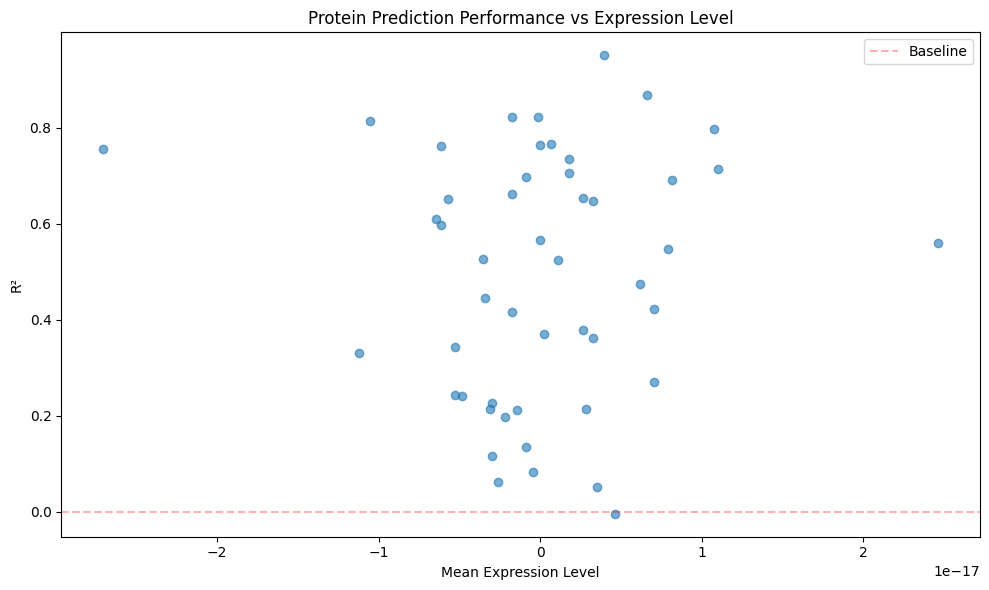


Correlation between mean expression and R²: 0.0369
Running with hyperparameters:
  max_neighbors: 20
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 128
  num_heads: 8
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 624,049
Epoch 1/3
  Train Loss: 0.7694
  Test Loss: 0.6217, MAE: 0.09, R²: 0.3521, Mean Protein R²: 0.4020, Pearson r: 0.6140
  Saved best model (R²: 0.3521)
Epoch 2/3
  Train Loss: 0.6851
  Test Loss: 0.5735, MAE: 0.08, R²: 0.3976, Mean Protein R²: 0.4635, Pearson r: 0.6413
  Saved best model (R²: 0.3976)
Epoch 3/3
  Train Loss: 0.6515
  Test Loss: 0.5592, MAE: 0.07, R²: 0.4068, Mean Protein R²: 0.4782, Pearson r: 0.6460
  Saved best model (R²: 0.4068)
Best predicted proteins:
Protein                                                  R²      

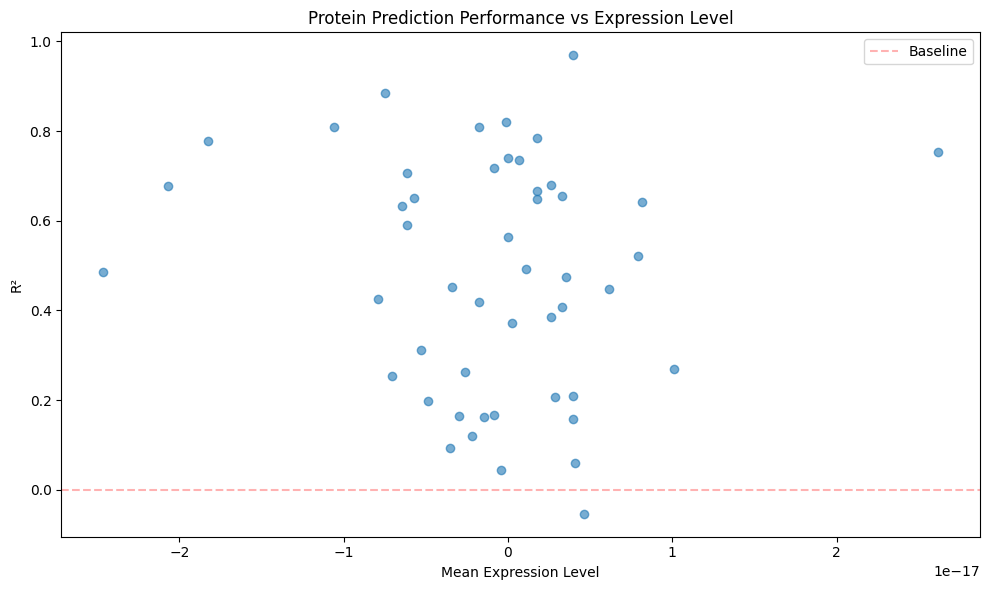


Correlation between mean expression and R²: -0.0914
Best R²: 0.4415793921924118
Best hyperparameters: {'hidden_dim': 256, 'num_heads': 4}


In [41]:
best_cap_indep = capacity_anchor
best_r2_indep = -float("inf")

for delta in capacity_sweep:
    params = {**capacity_anchor, **delta}

    r2 = run_and_score(
        best_graph | opt_anchor | params,
        rebuild_knn=False,
        test_baseline=False,
    )

    if r2 > best_r2_indep:
        best_r2_indep = r2
        best_cap_indep = params

print(f"Best R²: {best_r2_indep}")
print(f"Best hyperparameters: {best_cap_indep}")


Running with hyperparameters:
  max_neighbors: 20
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 64
  num_heads: 4
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 160,497
Epoch 1/3
  Train Loss: 0.8043
  Test Loss: 0.6927, MAE: 0.11, R²: 0.2821, Mean Protein R²: 0.3231, Pearson r: 0.5504
  Saved best model (R²: 0.2821)
Epoch 2/3
  Train Loss: 0.7225
  Test Loss: 0.6559, MAE: 0.10, R²: 0.3210, Mean Protein R²: 0.3662, Pearson r: 0.5907
  Saved best model (R²: 0.3210)
Epoch 3/3
  Train Loss: 0.6934
  Test Loss: 0.6275, MAE: 0.10, R²: 0.3491, Mean Protein R²: 0.4008, Pearson r: 0.6055
  Saved best model (R²: 0.3491)
Best predicted proteins:
Protein                                                  R²       Mean        Std        Max
-------------------------

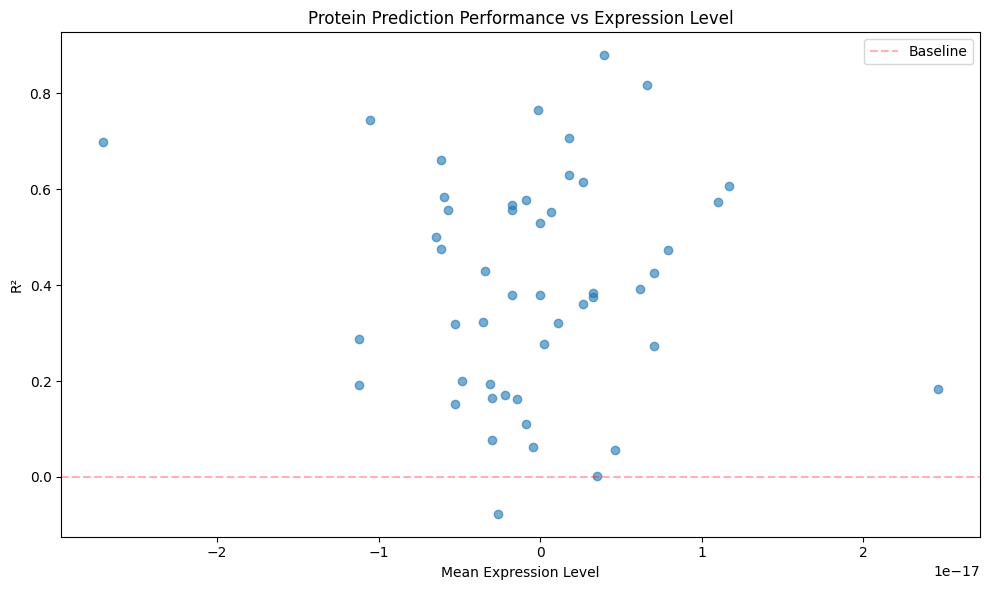


Correlation between mean expression and R²: -0.0506
Running with hyperparameters:
  max_neighbors: 20
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 256
  num_heads: 2
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 2,460,465
Epoch 1/3
  Train Loss: 0.7717
  Test Loss: 0.6176, MAE: 0.09, R²: 0.3550, Mean Protein R²: 0.4156, Pearson r: 0.6202
  Saved best model (R²: 0.3550)
Epoch 2/3
  Train Loss: 0.6958
  Test Loss: 0.6038, MAE: 0.09, R²: 0.3702, Mean Protein R²: 0.4245, Pearson r: 0.6140
  Saved best model (R²: 0.3702)
Epoch 3/3
  Train Loss: 0.6566
  Test Loss: 0.5499, MAE: 0.07, R²: 0.4204, Mean Protein R²: 0.4975, Pearson r: 0.6520
  Saved best model (R²: 0.4204)
Best predicted proteins:
Protein                                                  R²    

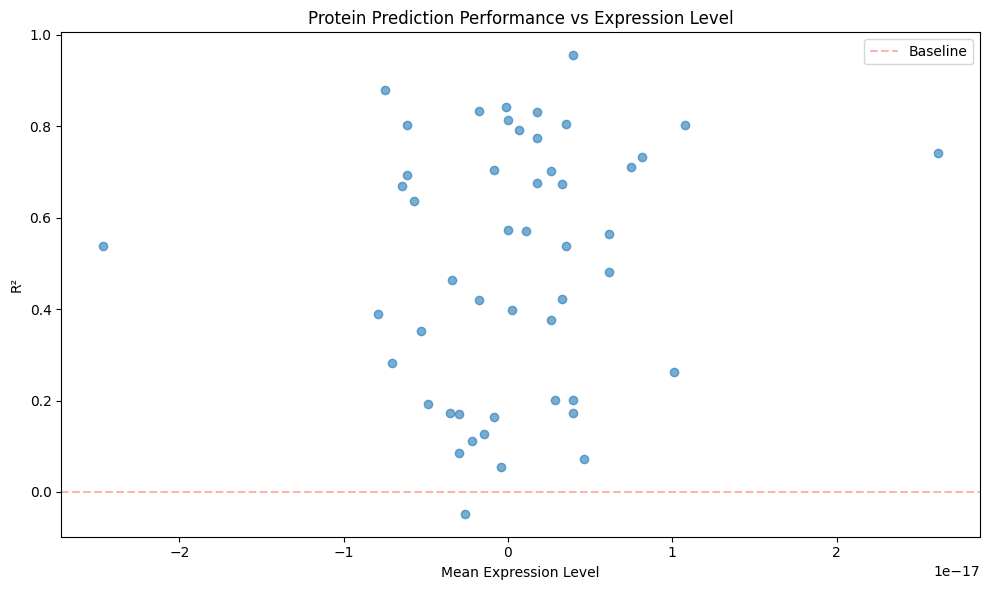


Correlation between mean expression and R²: 0.1417
Running with hyperparameters:
  max_neighbors: 20
  num_layers: 3
  lr: 0.001
  dropout: 0.1
  l2_reg: 1e-05
  hidden_dim: 256
  num_heads: 8
  rebuild_knn: False
  test_baseline: False
  num_epochs: 3

Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: -0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 2,460,465
Epoch 1/3
  Train Loss: 0.7621
  Test Loss: 0.6096, MAE: 0.09, R²: 0.3657, Mean Protein R²: 0.4145, Pearson r: 0.6257
  Saved best model (R²: 0.3657)
Epoch 2/3
  Train Loss: 0.6845
  Test Loss: 0.5681, MAE: 0.08, R²: 0.4083, Mean Protein R²: 0.4691, Pearson r: 0.6466
  Saved best model (R²: 0.4083)
Epoch 3/3
  Train Loss: 0.6495
  Test Loss: 0.5468, MAE: 0.07, R²: 0.4182, Mean Protein R²: 0.5007, Pearson r: 0.6506
  Saved best model (R²: 0.4182)
Best predicted proteins:
Protein                                                  R²    

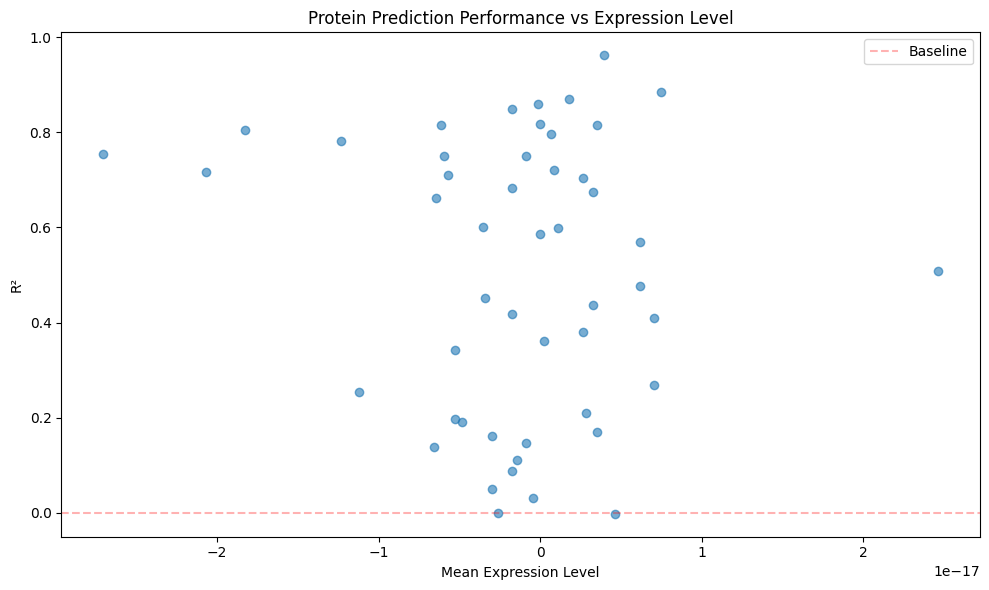


Correlation between mean expression and R²: -0.1038
Best R²: 0.4415793921924118
Best hyperparameters: {'hidden_dim': 256, 'num_heads': 4}


In [42]:
best_cap = best_cap_indep.copy()
best_r2 = best_r2_indep

for delta in capacity_sweep:
    params = {**best_cap, **delta}

    if params == best_cap:
        continue

    r2 = run_and_score(
        best_graph | opt_anchor | params,
        rebuild_knn=False,
        test_baseline=False,
    )

    if r2 > best_r2:
        best_r2 = r2
        best_cap = params

print(f"Best R²: {best_r2}")
print(f"Best hyperparameters: {best_cap}")

In [43]:
best_config = {
    **best_graph,
    **opt_anchor,
    **best_cap,
}

print("Final config:", best_config)


Final config: {'max_neighbors': 20, 'num_layers': 3, 'lr': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05, 'hidden_dim': 256, 'num_heads': 4}


Training on 49 protein markers
Normalizing protein expression (z-score per protein)...
After normalization - Mean: 0.0000, Std: 1.0000
Train samples: 204113, Test samples: 54272
Model parameters: 2,460,465
Epoch 1/20
  Train Loss: 0.7701
  Test Loss: 0.6419, MAE: 0.10, R²: 0.3272, Mean Protein R²: 0.3761, Pearson r: 0.5850
  Saved best model (R²: 0.3272)
Epoch 2/20
  Train Loss: 0.7051
  Test Loss: 0.5907, MAE: 0.09, R²: 0.3843, Mean Protein R²: 0.4321, Pearson r: 0.6413
  Saved best model (R²: 0.3843)
Epoch 3/20
  Train Loss: 0.6880
  Test Loss: 0.5713, MAE: 0.08, R²: 0.3952, Mean Protein R²: 0.4677, Pearson r: 0.6328
  Saved best model (R²: 0.3952)
Epoch 4/20
  Train Loss: 0.6759
  Test Loss: 0.6134, MAE: 0.09, R²: 0.3575, Mean Protein R²: 0.4265, Pearson r: 0.6066
Epoch 5/20
  Train Loss: 0.6668
  Test Loss: 0.5441, MAE: 0.07, R²: 0.4257, Mean Protein R²: 0.4883, Pearson r: 0.6572
  Saved best model (R²: 0.4257)
Epoch 6/20
  Train Loss: 0.6628
  Test Loss: 0.5791, MAE: 0.07, R²: 0.3

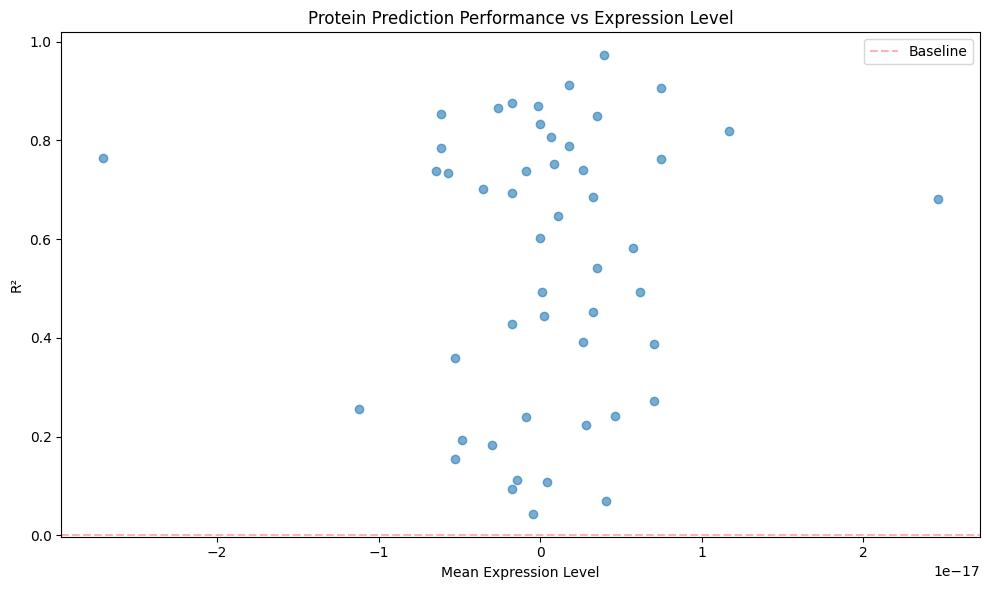


Correlation between mean expression and R²: 0.0513


In [45]:
model, _, _ = train_graphformer(
    df,
    protein_start_col=START_PROTEIN,
    protein_end_col=END_PROTEIN,
    normalize=True,
    num_epochs=20,
    rebuild_knn=False,
    test_baseline=False,
    **best_config,
)


In [46]:
import torch

# Save weights
torch.save(model.state_dict(), "graphformer_weights.pt")
